<a href="https://colab.research.google.com/github/FelipeBuitragoC/CAD_Tuberculosis/blob/main/segmentacion_rx.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

---

# Técnicas de Segmentación en Radiografías de Tórax

**Autora:** Maria Bernarda Salazar Sánchez

Este notebook documenta y ejemplifica las principales técnicas de segmentación aplicadas a radiografías de tórax en sistemas CAD. Cada sección incluye definición, contexto clínico, implementación práctica y visualización sobre la imagen de referencia del repositorio.

> **Imagen de referencia:** `reports/figures/Rx-example.jpg`

---

<a id="toc"></a>

## Tabla de Contenidos

| # | Sección |
|---|---------|
| 1 | [Configuración e imagen de referencia](#setup) |
| 2 | [¿Qué es la segmentación?](#definicion) |
| 3 | [Métodos clásicos basados en intensidad](#intensidad) |
| 3.1 | [Umbralización — Otsu](#otsu) |
| 3.2 | [Umbralización Adaptativa](#adaptativa) |
| 3.3 | [Region Growing](#region_growing) |
| 3.4 | [Watershed](#watershed) |
| 3.5 | [Active Contours — Snake](#snake) |
| 4 | [Métodos basados en características y bordes](#bordes) |
| 4.1 | [Detección de bordes — Canny / Sobel / Laplacian](#canny) |
| 4.2 | [Filtros de Gabor y multiescala](#gabor) |
| 5 | [Métodos de Clustering](#clustering) |
| 5.1 | [K-Means](#kmeans) |
| 5.2 | [Fuzzy C-Means](#fcm) |
| 5.3 | [Gaussian Mixture Models](#gmm) |
| 6 | [Aprendizaje automático clásico](#ml_clasico) |
| 7 | [Deep Learning](#deep_learning) |
| 8 | [Modelos recientes](#recientes) |
| 9 | [Comparativa Visual](#comparativa) |
|   | [Referencias](#referencias) |

---

<a id="setup"></a>

## 1. Configuración e imagen de referencia

La siguiente celda instala las dependencias necesarias y carga la imagen desde la URL pública del repositorio.

Cargando: https://raw.githubusercontent.com/FelipeBuitragoC/CAD_Tuberculosis/main/reports/figures/Rx-example.jpg
Imagen lista | tamaño: (512, 512) | rango: [0.000, 0.959]


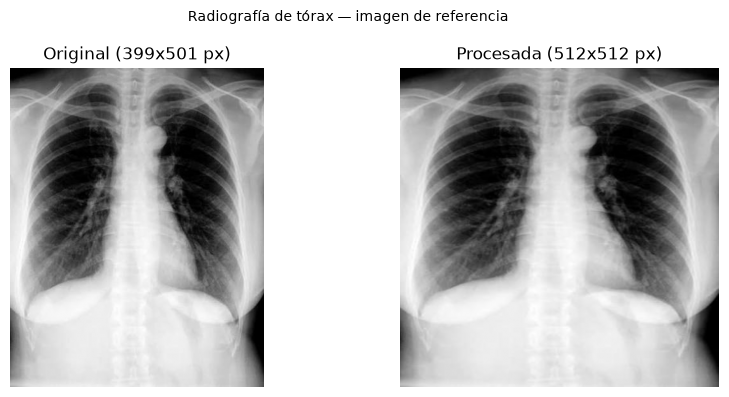

In [25]:
import subprocess, sys
for pkg in ["scikit-image", "matplotlib", "numpy", "scipy", "pillow", "scikit-learn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage import img_as_ubyte, img_as_float
from skimage.transform import resize
from PIL import Image
import urllib.request, io

IMG_URL = "https://raw.githubusercontent.com/FelipeBuitragoC/CAD_Tuberculosis/main/reports/figures/Rx-example.jpg"

print(f"Cargando: {IMG_URL}")
with urllib.request.urlopen(IMG_URL) as r:
    img_raw = np.array(Image.open(io.BytesIO(r.read())).convert("L"))

TARGET    = 512
img       = img_as_float(img_raw)
img       = resize(img, (TARGET, TARGET), anti_aliasing=True)
img_uint8 = img_as_ubyte(img)

print(f"Imagen lista | tamaño: {img.shape} | rango: [{img.min():.3f}, {img.max():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img_raw, cmap="gray")
axes[0].set_title(f"Original ({img_raw.shape[1]}x{img_raw.shape[0]} px)")
axes[0].axis("off")
axes[1].imshow(img, cmap="gray")
axes[1].set_title(f"Procesada ({TARGET}x{TARGET} px)")
axes[1].axis("off")
fig.suptitle("Radiografía de tórax — imagen de referencia", fontsize=10)
plt.tight_layout()
plt.show()

<a id="definicion"></a>

## 2. ¿Qué es la Segmentación?

> La segmentación es el proceso de dividir una imagen en regiones significativas y homogéneas con el objetivo de aislar estructuras de interés clínico.

En radiografías de tórax, la segmentación permite delimitar estructuras como los **campos pulmonares**, el **mediastino**, la **silueta cardíaca** y posibles **lesiones** (nódulos, consolidaciones, cavidades). Es un paso previo indispensable para la extracción de características y la clasificación automática de enfermedades (Candemir & Antani, 2019).

Las familias de técnicas de segmentación, ordenadas de menor a mayor complejidad, son:

| Familia | Ejemplos | Requiere datos etiquetados |
|---------|----------|--------------------------|
| Basadas en intensidad | Otsu, Watershed, Snakes | No |
| Basadas en borde | Canny, Sobel, Gabor | No |
| Clustering | K-Means, FCM, GMM | No |
| ML clásico | SVM, Random Forest | Sí |
| Deep Learning | U-Net, Attention U-Net | Sí (muchos) |
| Modelos recientes | nnU-Net, SAM, Swin Transformer | Sí (o zero-shot) |

[Volver a la Tabla de Contenidos](#toc)

---

<a id="intensidad"></a>

## 3. Métodos Clásicos Basados en Intensidad

> Trabajan directamente sobre los niveles de gris de la imagen, sin necesidad de datos de entrenamiento.

Son los métodos más interpretables y los primeros históricamente aplicados en imágenes médicas. Su principio común es explotar la distribución de intensidades para separar regiones anatómicas.

**Ventaja:** simples, rápidos e interpretables.  
**Limitación en RX:** la superposición de estructuras (costillas, mediastino, vasos) y los bordes poco definidos dificultan la segmentación precisa (Mansoor et al., 2015).

[Volver a la Tabla de Contenidos](#toc)

---

<a id="otsu"></a>

### 3.1 Umbralización — Método de Otsu
### *Global Thresholding*

La umbralización convierte la imagen en binaria eligiendo un valor de corte τ. El **método de Otsu** (1979) determina τ automáticamente maximizando la varianza interclase entre los dos grupos resultantes.

**Criterio de optimización:**

`τ* = argmax [ w₀(τ) · w₁(τ) · (μ₀(τ) − μ₁(τ))² ]`

donde w₀, w₁ son las probabilidades de pertenencia a cada clase y μ₀, μ₁ sus medias de intensidad.

**Limitación:** al ser global, falla ante iluminación no uniforme, frecuente en RX por el gradiente del mediastino (Otsu, 1979).

[Volver a la Tabla de Contenidos](#toc)

Umbral de Otsu: 0.5040  (128.5 / 255)


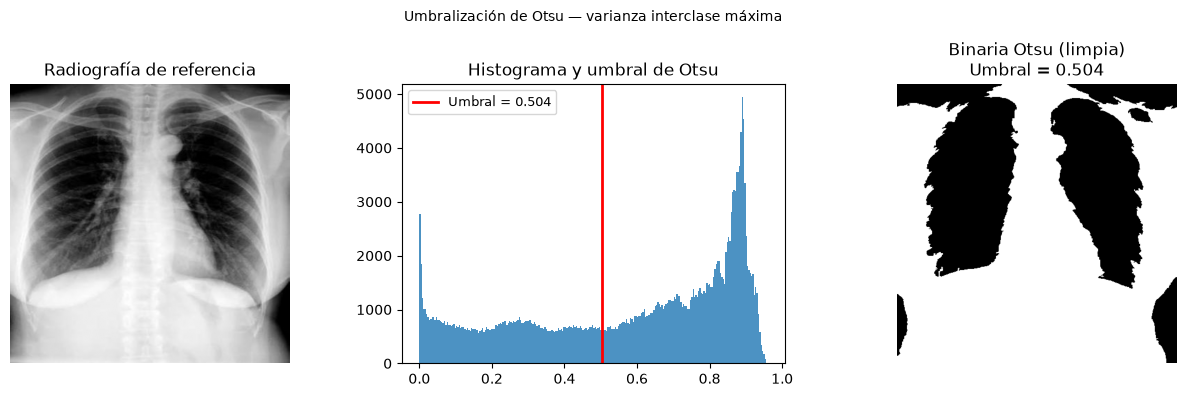

In [26]:
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes

thresh_otsu   = threshold_otsu(img)
binary_otsu   = img > thresh_otsu
binary_otsu_c = remove_small_objects(binary_otsu, min_size=200)
binary_otsu_c = remove_small_holes(binary_otsu_c, area_threshold=500)

print(f"Umbral de Otsu: {thresh_otsu:.4f}  ({thresh_otsu*255:.1f} / 255)")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Radiografía de referencia"); axes[0].axis("off")
axes[1].hist(img.ravel(), bins=256, color="#1f77b4", edgecolor="none", alpha=0.8)
axes[1].axvline(thresh_otsu, color="red", lw=2, label=f"Umbral = {thresh_otsu:.3f}")
axes[1].set_title("Histograma y umbral de Otsu"); axes[1].legend(fontsize=9)
axes[2].imshow(binary_otsu_c, cmap="gray")
axes[2].set_title(f"Binaria Otsu (limpia)\nUmbral = {thresh_otsu:.3f}"); axes[2].axis("off")
fig.suptitle("Umbralización de Otsu — varianza interclase máxima", fontsize=10)
plt.tight_layout(); plt.show()

<a id="adaptativa"></a>

### 3.2 Umbralización Adaptativa
### *Local / Adaptive Thresholding*

Calcula un umbral diferente para cada píxel en función de la intensidad media de su vecindario local de tamaño *w×w*. Robusta ante variaciones locales de iluminación y contraste (Bradley & Roth, 2007).

**Umbral local:** `τ(x,y) = media(vecindario_w) − C`

**Ventaja clínica:** detecta lesiones tenues en zonas de baja intensidad relativa que un umbral global ignoraría.

[Volver a la Tabla de Contenidos](#toc)

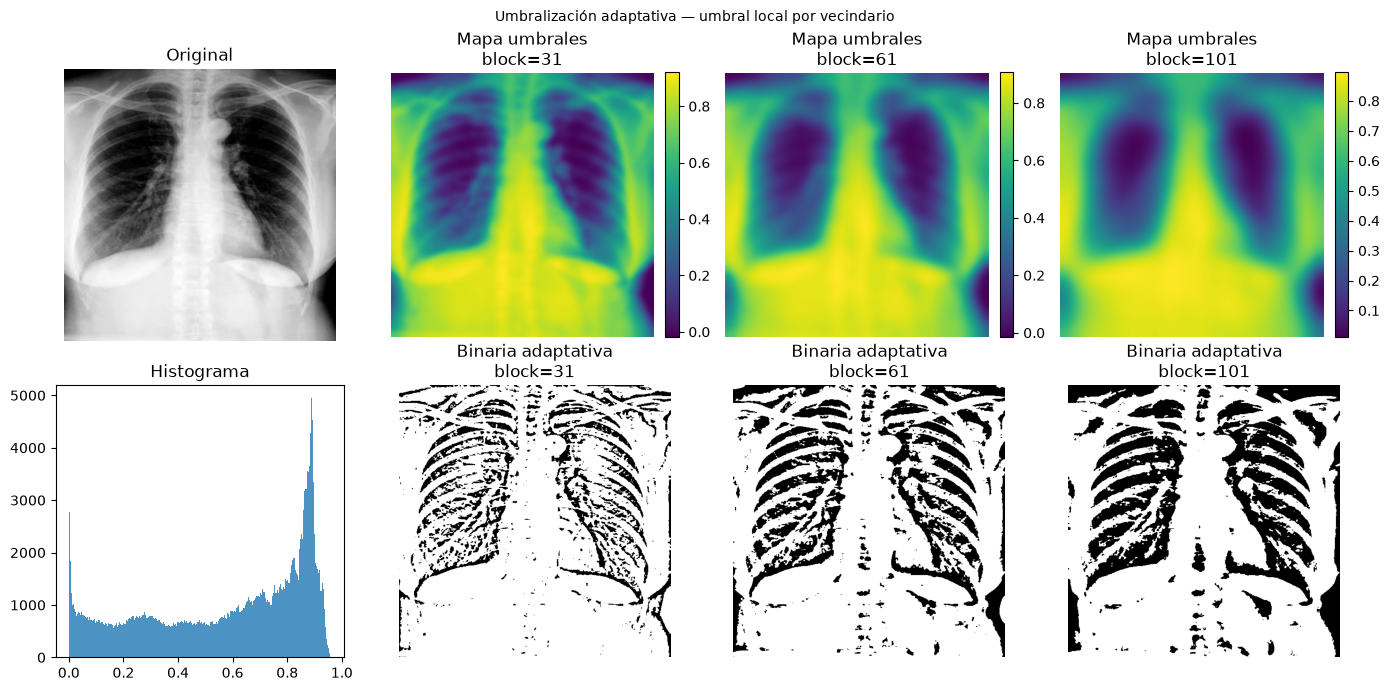

In [27]:
from skimage.filters import threshold_local

block_sizes = [31, 61, 101]
offset      = 0.02

fig, axes = plt.subplots(2, len(block_sizes)+1, figsize=(14, 7))
axes[0,0].imshow(img, cmap="gray"); axes[0,0].set_title("Original"); axes[0,0].axis("off")
axes[1,0].hist(img.ravel(), bins=256, color="#1f77b4", edgecolor="none", alpha=0.8)
axes[1,0].set_title("Histograma")

for idx, bs in enumerate(block_sizes):
    local_thresh = threshold_local(img, block_size=bs, offset=offset)
    binary_local = img > local_thresh
    im_t = axes[0,idx+1].imshow(local_thresh, cmap="viridis")
    axes[0,idx+1].set_title(f"Mapa umbrales\nblock={bs}"); axes[0,idx+1].axis("off")
    plt.colorbar(im_t, ax=axes[0,idx+1], fraction=0.046, pad=0.04)
    axes[1,idx+1].imshow(binary_local, cmap="gray")
    axes[1,idx+1].set_title(f"Binaria adaptativa\nblock={bs}"); axes[1,idx+1].axis("off")

fig.suptitle("Umbralización adaptativa — umbral local por vecindario", fontsize=10)
plt.tight_layout(); plt.show()

<a id="region_growing"></a>

### 3.3 Region Growing
### *Crecimiento de Regiones*

Parte de uno o varios **puntos semilla** (*seeds*) y agrega iterativamente los píxeles vecinos cuya intensidad no supere un umbral de similaridad Δ respecto a la media de la región creciente. El proceso termina cuando ningún píxel vecino satisface el criterio (Adams & Bischof, 1994).

**Criterio de inclusión:**

`|I(p) − μ_región| ≤ Δ`

**Uso clínico:** segmentación de nódulos pulmonares o cavidades tuberculosas partiendo de un punto inicial en la lesión. Muy sensible a la elección de la semilla y de Δ (Mansoor et al., 2015).

[Volver a la Tabla de Contenidos](#toc)

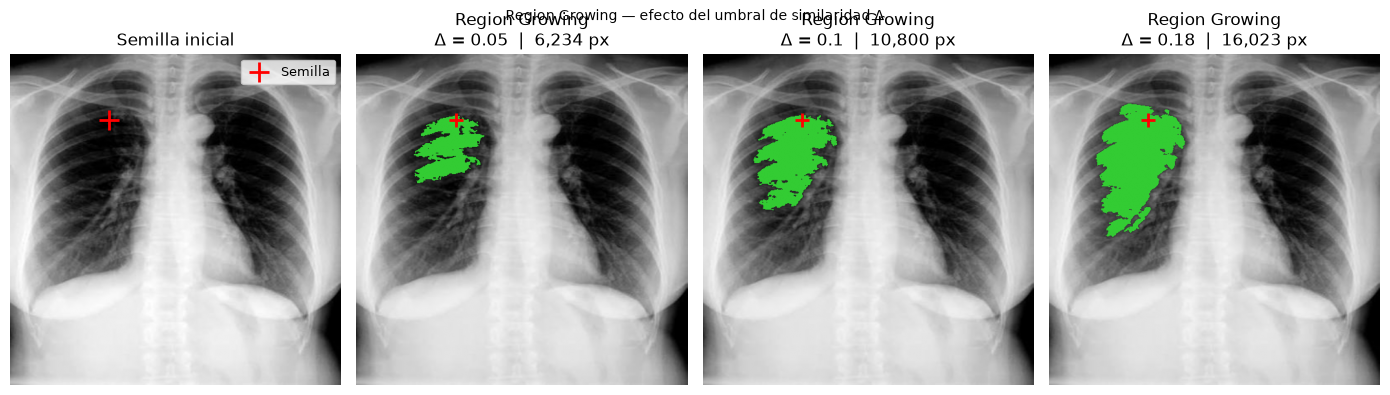

In [28]:
from collections import deque

def region_growing(image, seed, delta):
    """Region growing desde una semilla con tolerancia delta."""
    H, W   = image.shape
    visited = np.zeros((H, W), dtype=bool)
    region  = np.zeros((H, W), dtype=bool)
    queue   = deque([seed])
    visited[seed] = True
    seed_val = image[seed]

    while queue:
        r, c = queue.popleft()
        if abs(image[r, c] - seed_val) <= delta:
            region[r, c] = True
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0<=nr<H and 0<=nc<W and not visited[nr,nc]:
                    visited[nr,nc] = True
                    queue.append((nr,nc))
    return region

# Semilla en zona de alta densidad (zona apical izquierda)
seed   = (int(TARGET*0.20), int(TARGET*0.30))
deltas = [0.05, 0.10, 0.18]

fig, axes = plt.subplots(1, len(deltas)+1, figsize=(14, 4))
axes[0].imshow(img, cmap="gray")
axes[0].plot(seed[1], seed[0], "r+", ms=14, mew=2, label="Semilla")
axes[0].legend(fontsize=9); axes[0].set_title("Semilla inicial"); axes[0].axis("off")

for idx, d in enumerate(deltas):
    reg = region_growing(img, seed, d)
    overlay = np.stack([img,img,img], axis=-1)
    overlay[reg] = [0.2, 0.8, 0.2]
    axes[idx+1].imshow(overlay)
    axes[idx+1].plot(seed[1], seed[0], "r+", ms=10, mew=2)
    axes[idx+1].set_title(f"Region Growing\nΔ = {d}  |  {reg.sum():,} px")
    axes[idx+1].axis("off")

fig.suptitle("Region Growing — efecto del umbral de similaridad Δ", fontsize=10)
plt.tight_layout(); plt.show()

<a id="watershed"></a>

### 3.4 Watershed
### *Transformada de Cuencas Hidrográficas*

Trata la imagen como un relieve topográfico donde la intensidad representa la altitud. Se "inunda" el terreno desde marcadores semilla; cuando dos cuencas se encuentran se levanta una **línea divisoria** (Beucher & Lantuéjoul, 1979).

**Flujo típico:**
1. Calcular el mapa de gradiente.
2. Definir marcadores (semillas para fondo y objeto).
3. Aplicar Watershed sobre el gradiente.

**Ventaja clínica:** captura bordes débiles y separa estructuras solapadas como lóbulos pulmonares (Mansoor et al., 2015).

[Volver a la Tabla de Contenidos](#toc)

Regiones segmentadas: 0


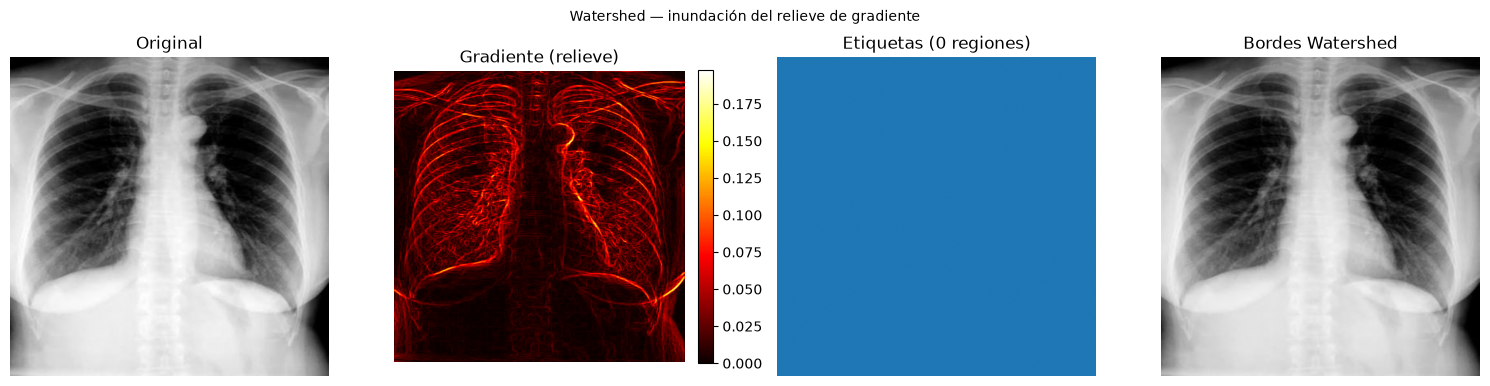

In [29]:
from skimage.filters import sobel, gaussian
from skimage.segmentation import watershed, mark_boundaries
from skimage.feature import peak_local_max
from scipy import ndimage as ndi

gradient    = sobel(img)
smooth_grad = gaussian(gradient, sigma=2)
local_min   = peak_local_max(-smooth_grad, min_distance=20,
                              threshold_rel=0.05, exclude_border=False)
marker_mask = np.zeros(img.shape, dtype=bool)
marker_mask[tuple(local_min.T)] = True
markers, _  = ndi.label(marker_mask)
labels_ws   = watershed(gradient, markers)

print(f"Regiones segmentadas: {labels_ws.max()}")

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
im_g = axes[1].imshow(gradient, cmap="hot"); axes[1].set_title("Gradiente (relieve)"); axes[1].axis("off")
plt.colorbar(im_g, ax=axes[1], fraction=0.046, pad=0.04)
axes[2].imshow(labels_ws, cmap="tab20"); axes[2].set_title(f"Etiquetas ({labels_ws.max()} regiones)"); axes[2].axis("off")
axes[3].imshow(mark_boundaries(img, labels_ws, color=(1,0.2,0.2)))
axes[3].set_title("Bordes Watershed"); axes[3].axis("off")
fig.suptitle("Watershed — inundación del relieve de gradiente", fontsize=10)
plt.tight_layout(); plt.show()

<a id="snake"></a>

### 3.5 Contornos Activos — Snake
### *Active Contours*

Curva paramétrica que se deforma iterativamente bajo energías internas (rigidez y elasticidad) y externas (gradiente de la imagen) hasta converger sobre el borde de la estructura (Kass, Witkin & Terzopoulos, 1988).

**Función de energía:**

`E = ∫ [ α|v'(s)|² + β|v''(s)|² − |∇I(v(s))|² ] ds`

- **α** (elasticidad): controla la longitud del contorno.
- **β** (rigidez): controla la curvatura.
- **∇I**: atrae el contorno hacia los bordes.

**Uso clínico:** delimitación precisa de campos pulmonares y silueta cardíaca; requiere inicialización cercana a la estructura (Mansoor et al., 2015).

[Volver a la Tabla de Contenidos](#toc)

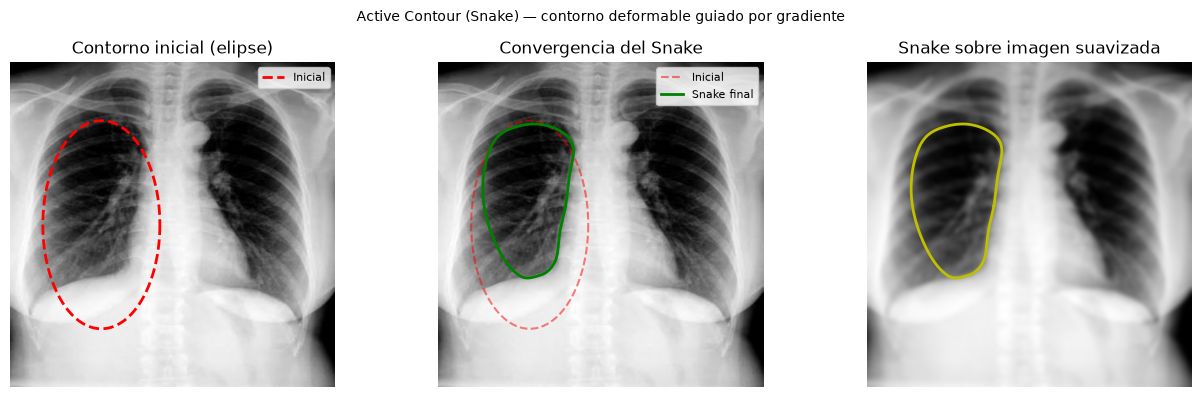

In [30]:
from skimage.segmentation import active_contour

img_smooth = gaussian(img, sigma=3)

cx, cy = TARGET*0.28, TARGET*0.50
rx, ry = TARGET*0.18, TARGET*0.32
theta  = np.linspace(0, 2*np.pi, 400)
init_r = cy + ry*np.sin(theta)
init_c = cx + rx*np.cos(theta)
init   = np.column_stack([init_r, init_c])

snake = active_contour(img_smooth, init, alpha=0.015, beta=10,
                       gamma=0.001, max_num_iter=250)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img, cmap="gray")
axes[0].plot(init_c, init_r, "--r", lw=2, label="Inicial"); axes[0].legend(fontsize=8)
axes[0].set_title("Contorno inicial (elipse)"); axes[0].axis("off")

axes[1].imshow(img, cmap="gray")
axes[1].plot(init_c, init_r, "--r", lw=1.5, alpha=0.5, label="Inicial")
axes[1].plot(snake[:,1], snake[:,0], "-g", lw=2, label="Snake final"); axes[1].legend(fontsize=8)
axes[1].set_title("Convergencia del Snake"); axes[1].axis("off")

axes[2].imshow(img_smooth, cmap="gray")
axes[2].plot(snake[:,1], snake[:,0], "-y", lw=2)
axes[2].set_title("Snake sobre imagen suavizada"); axes[2].axis("off")

fig.suptitle("Active Contour (Snake) — contorno deformable guiado por gradiente", fontsize=10)
plt.tight_layout(); plt.show()

<a id="bordes"></a>

## 4. Métodos Basados en Características y Bordes

> Detectan discontinuidades de intensidad para identificar límites anatómicos, sin requerir datos de entrenamiento.

Los detectores de bordes son la base de muchos pipelines de segmentación: generan mapas de gradiente que luego se usan como entrada para Watershed o como características para clasificadores (Canny, 1986).

[Volver a la Tabla de Contenidos](#toc)

---

<a id="canny"></a>

### 4.1 Detección de Bordes — Canny / Sobel / Laplacian

| Detector | Principio | Sensibilidad al ruido |
|----------|-----------|----------------------|
| **Sobel** | Gradiente de primer orden (diferencias finitas) | Alta |
| **Laplacian** | Derivada de segundo orden (cruces por cero) | Muy alta |
| **Canny** | Gradiente + supresión no máxima + histéresis | Baja (por suavizado previo) |

El **detector de Canny** (1986) es el estándar de referencia: suaviza con gaussiana (σ), calcula el gradiente, adelgaza los bordes por supresión no máxima y aplica umbralización por histéresis con T_low y T_high.

[Volver a la Tabla de Contenidos](#toc)

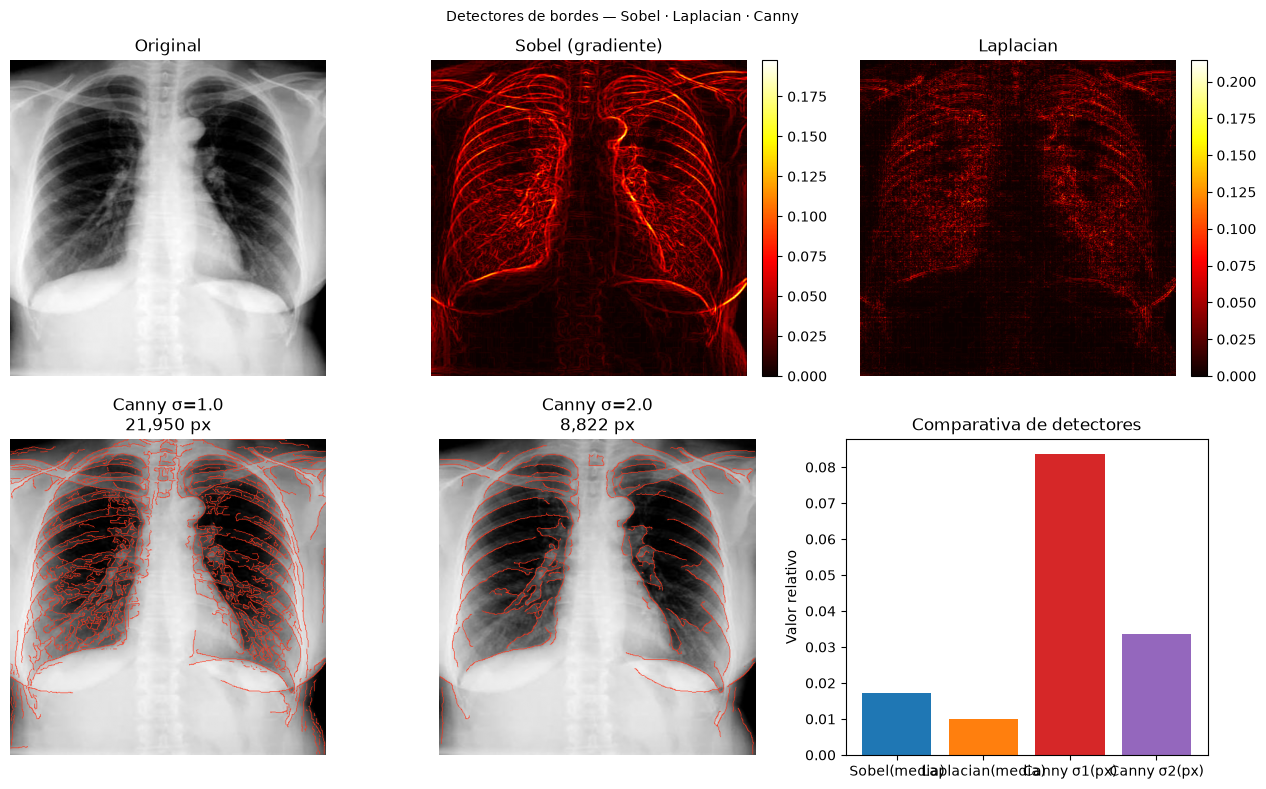

In [31]:
from skimage.feature import canny
from skimage.filters import sobel, laplace, gaussian

edges_sobel   = sobel(img)
edges_lap     = np.abs(laplace(img))
edges_canny_1 = canny(img, sigma=1.0, low_threshold=0.05, high_threshold=0.15)
edges_canny_2 = canny(img, sigma=2.0, low_threshold=0.05, high_threshold=0.20)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes[0,0].imshow(img, cmap="gray"); axes[0,0].set_title("Original"); axes[0,0].axis("off")

im_s = axes[0,1].imshow(edges_sobel, cmap="hot"); axes[0,1].set_title("Sobel (gradiente)"); axes[0,1].axis("off")
plt.colorbar(im_s, ax=axes[0,1], fraction=0.046, pad=0.04)

im_l = axes[0,2].imshow(edges_lap, cmap="hot"); axes[0,2].set_title("Laplacian"); axes[0,2].axis("off")
plt.colorbar(im_l, ax=axes[0,2], fraction=0.046, pad=0.04)

ov1 = np.stack([img]*3,-1); ov1[edges_canny_1] = [1.,0.2,0.1]
axes[1,0].imshow(ov1); axes[1,0].set_title(f"Canny σ=1.0\n{edges_canny_1.sum():,} px"); axes[1,0].axis("off")

ov2 = np.stack([img]*3,-1); ov2[edges_canny_2] = [1.,0.2,0.1]
axes[1,1].imshow(ov2); axes[1,1].set_title(f"Canny σ=2.0\n{edges_canny_2.sum():,} px"); axes[1,1].axis("off")

axes[1,2].bar(["Sobel(media)", "Laplacian(media)", "Canny σ1(px)", "Canny σ2(px)"],
              [edges_sobel.mean(), edges_lap.mean(),
               edges_canny_1.sum()/img.size, edges_canny_2.sum()/img.size],
              color=["#1f77b4","#ff7f0e","#d62728","#9467bd"])
axes[1,2].set_ylabel("Valor relativo"); axes[1,2].set_title("Comparativa de detectores")

fig.suptitle("Detectores de bordes — Sobel · Laplacian · Canny", fontsize=10)
plt.tight_layout(); plt.show()

<a id="gabor"></a>

### 4.2 Filtros de Gabor y Multiescala

Un **filtro de Gabor** combina una gaussiana con una sinusoide, siendo selectivo en frecuencia y orientación. Es especialmente útil para detectar texturas y estructuras orientadas como vasos o costillas (Jain & Farrokhnia, 1991).

El **filtrado multiescala** (p. ej., diferencia de gaussianas — DoG) analiza la imagen a varias escalas simultáneamente, capturando estructuras de diferentes tamaños.

[Volver a la Tabla de Contenidos](#toc)

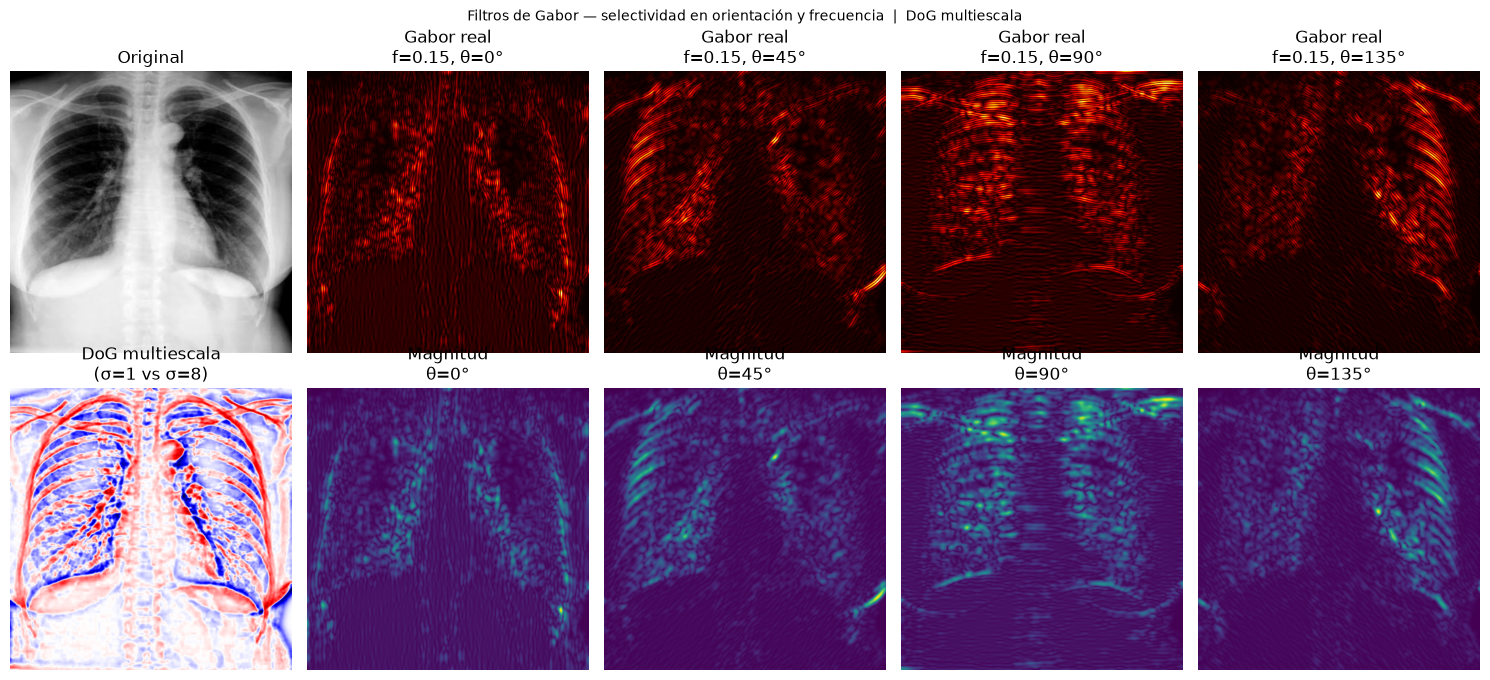

In [32]:
from skimage.filters import gabor, gaussian as gauss

orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
frequency    = 0.15

fig, axes = plt.subplots(2, len(orientations)+1, figsize=(15, 7))
axes[0,0].imshow(img, cmap="gray"); axes[0,0].set_title("Original"); axes[0,0].axis("off")

# DoG multiescala
dog = gauss(img, sigma=1) - gauss(img, sigma=8)
axes[1,0].imshow(dog, cmap="seismic", vmin=-dog.max(), vmax=dog.max())
axes[1,0].set_title("DoG multiescala\n(σ=1 vs σ=8)"); axes[1,0].axis("off")

for idx, theta in enumerate(orientations):
    real, imag = gabor(img, frequency=frequency, theta=theta)
    magnitude  = np.sqrt(real**2 + imag**2)
    deg        = int(np.degrees(theta))

    im_r = axes[0,idx+1].imshow(np.abs(real), cmap="hot")
    axes[0,idx+1].set_title(f"Gabor real\nf={frequency}, θ={deg}°"); axes[0,idx+1].axis("off")

    im_m = axes[1,idx+1].imshow(magnitude, cmap="viridis")
    axes[1,idx+1].set_title(f"Magnitud\nθ={deg}°"); axes[1,idx+1].axis("off")

fig.suptitle("Filtros de Gabor — selectividad en orientación y frecuencia  |  DoG multiescala", fontsize=10)
plt.tight_layout(); plt.show()

<a id="clustering"></a>

## 5. Métodos de Clustering

> Agrupan píxeles con características similares —intensidad, textura o posición— sin supervisión. No requieren datos etiquetados.

Son especialmente útiles cuando no se dispone de anotaciones y se quiere una primera aproximación a la segmentación de regiones con diferente densidad radiológica (Mansoor et al., 2015).

[Volver a la Tabla de Contenidos](#toc)

---

<a id="kmeans"></a>

### 5.1 K-Means

Particiona los píxeles en **K clústeres** minimizando la suma de distancias cuadráticas al centroide. K=3 separa típicamente fondo / tejido blando / estructuras densas en RX de tórax (MacQueen, 1967).

[Volver a la Tabla de Contenidos](#toc)

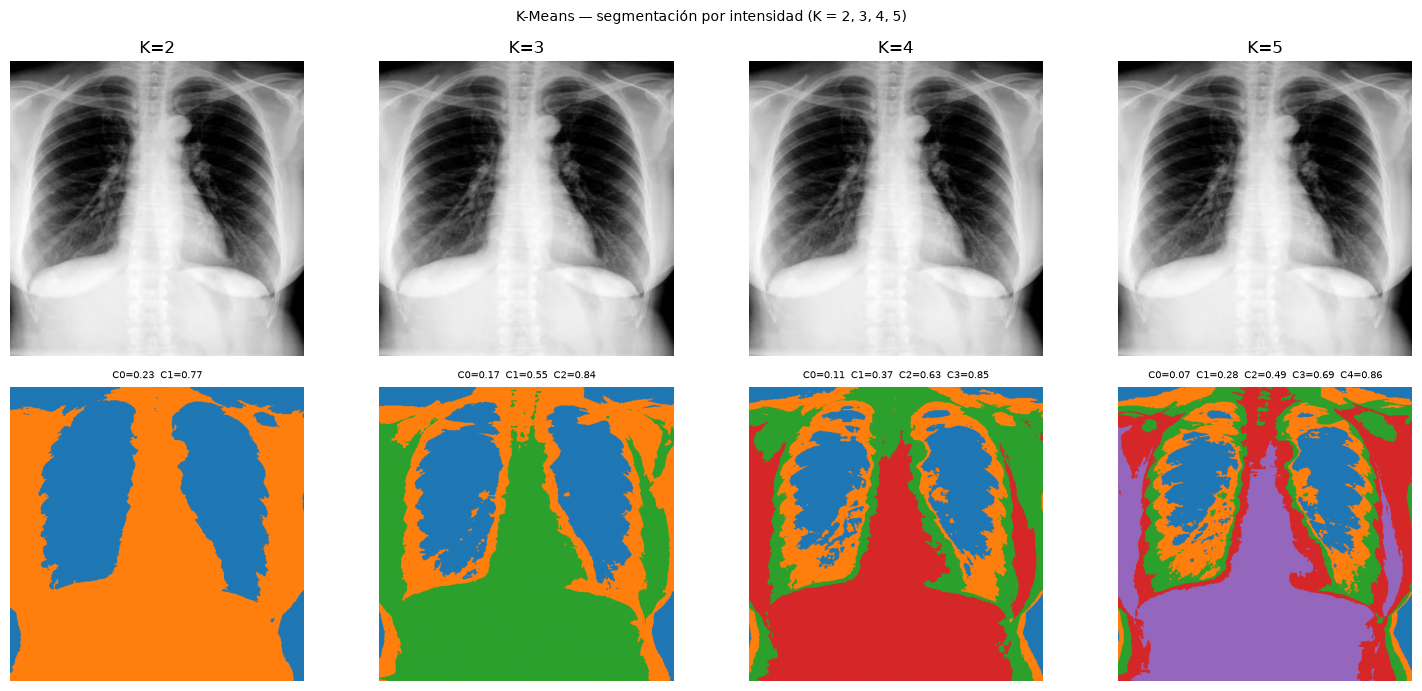

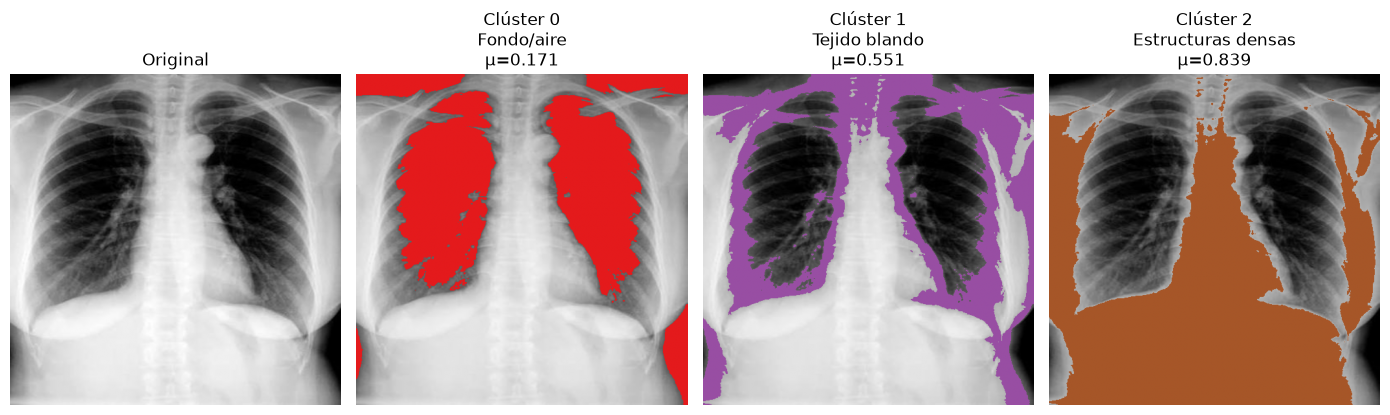

In [40]:
from sklearn.cluster import MiniBatchKMeans

pixels   = img.reshape(-1,1).astype(np.float32)
k_values = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 4, figsize=(15,7))
cluster_names = ["Fondo/aire", "Tejido blando", "Estructuras densas"]

for idx, k in enumerate(k_values):
    km      = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5)
    labels_ = km.fit_predict(pixels).reshape(img.shape)
    order   = np.argsort(km.cluster_centers_.ravel())
    remap   = {old:new for new,old in enumerate(order)}
    labels_s= np.vectorize(remap.get)(labels_)

    axes[0,idx].imshow(img, cmap="gray"); axes[0,idx].set_title(f"K={k}"); axes[0,idx].axis("off")
    axes[1,idx].imshow(labels_s, cmap="tab10", vmin=0, vmax=9)
    cents = np.sort(km.cluster_centers_.ravel())
    axes[1,idx].set_title("  ".join([f"C{i}={v:.2f}" for i,v in enumerate(cents)]), fontsize=7)
    axes[1,idx].axis("off")

fig.suptitle("K-Means — segmentación por intensidad (K = 2, 3, 4, 5)", fontsize=10)
plt.tight_layout(); plt.show()

# Detalle K=3 por clúster
k = 3
km3    = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5)
lab3   = km3.fit_predict(pixels).reshape(img.shape)
ord3   = np.argsort(km3.cluster_centers_.ravel())
rem3   = {old:new for new,old in enumerate(ord3)}
lab3_s = np.vectorize(rem3.get)(lab3)

fig2, axes2 = plt.subplots(1,4,figsize=(14,4))
axes2[0].imshow(img,cmap="gray"); axes2[0].set_title("Original"); axes2[0].axis("off")
for c in range(k):
    ov = np.stack([img]*3,-1); mask_c=(lab3_s==c); ov[mask_c]=plt.cm.Set1(c/k)[:3]
    axes2[c+1].imshow(ov)
    lbl = cluster_names[c] if c<len(cluster_names) else f"Clúster {c}"
    axes2[c+1].set_title(f"Clúster {c}\n{lbl}\nμ={km3.cluster_centers_.ravel()[ord3[c]]:.3f}")
    axes2[c+1].axis("off")
plt.tight_layout(); plt.show()

<a id="fcm"></a>

### 5.2 Fuzzy C-Means (FCM)

A diferencia de K-Means, FCM asigna a cada píxel un **grado de pertenencia** (entre 0 y 1) a cada clúster, en lugar de una asignación dura. Esto lo hace más adecuado para imágenes médicas donde los bordes entre tejidos son difusos (Bezdek, Hall & Clarke, 1993).

**Función objetivo:**

`J = Σᵢ Σⱼ uᵢⱼᵐ · ||xⱼ − cᵢ||²`

donde uᵢⱼ es el grado de pertenencia del píxel j al clúster i, y m > 1 es el exponente de difusidad.

> **Nota:** scikit-learn no incluye FCM nativo. La implementación a continuación usa NumPy directamente.

[Volver a la Tabla de Contenidos](#toc)

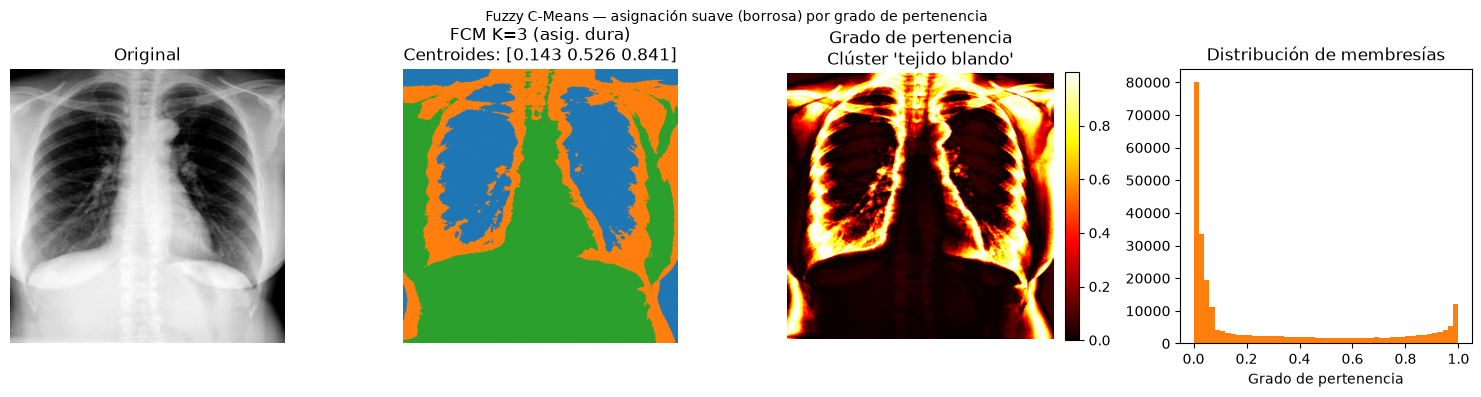

In [34]:
def fuzzy_cmeans(X, n_clusters=3, m=2.0, max_iter=100, tol=1e-4, random_state=42):
    """Fuzzy C-Means simplificado sobre array 1D de píxeles."""
    rng = np.random.default_rng(random_state)
    n   = len(X)
    # Inicializar grados de pertenencia aleatoriamente
    U   = rng.dirichlet(np.ones(n_clusters), size=n)   # (n, K)
    for _ in range(max_iter):
        Um   = U ** m                                   # (n, K)
        C    = (Um.T @ X) / Um.sum(axis=0)             # centroides (K,)
        dist = np.abs(X[:,None] - C[None,:]) + 1e-10   # (n, K)
        U_new = (1.0 / dist) ** (2/(m-1))
        U_new = U_new / U_new.sum(axis=1, keepdims=True)
        if np.max(np.abs(U_new - U)) < tol:
            break
        U = U_new
    labels = np.argmax(U, axis=1)
    return labels, C, U

pixels_1d = img.ravel().astype(np.float32)
fcm_labels, fcm_centers, fcm_U = fuzzy_cmeans(pixels_1d, n_clusters=3)

# Reordenar clústeres de oscuro a claro
order_fcm  = np.argsort(fcm_centers)
remap_fcm  = {old:new for new,old in enumerate(order_fcm)}
fcm_labels_s = np.vectorize(remap_fcm.get)(fcm_labels).reshape(img.shape)
# Mapa de grado de pertenencia al clúster "tejido" (clúster 1)
memberships = fcm_U[:, order_fcm[1]].reshape(img.shape)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(fcm_labels_s, cmap="tab10", vmin=0, vmax=9)
axes[1].set_title(f"FCM K=3 (asig. dura)\nCentroides: {np.sort(fcm_centers).round(3)}"); axes[1].axis("off")
im_m = axes[2].imshow(memberships, cmap="hot")
axes[2].set_title("Grado de pertenencia\nClúster 'tejido blando'"); axes[2].axis("off")
plt.colorbar(im_m, ax=axes[2], fraction=0.046, pad=0.04)
axes[3].hist(memberships.ravel(), bins=50, color="#ff7f0e", edgecolor="none")
axes[3].set_xlabel("Grado de pertenencia"); axes[3].set_title("Distribución de membresías")
fig.suptitle("Fuzzy C-Means — asignación suave (borrosa) por grado de pertenencia", fontsize=10)
plt.tight_layout(); plt.show()

<a id="gmm"></a>

### 5.3 Gaussian Mixture Models (GMM)

Los GMM modelan la distribución de intensidades de la imagen como una mezcla de K gaussianas. Cada componente representa una región con media y varianza propias. El ajuste se realiza mediante el algoritmo **EM** (Expectation-Maximization) (Dempster, Laird & Rubin, 1977).

**Ventaja sobre K-Means:** captura la forma de la distribución de cada región, no solo su centroide. Permite obtener probabilidades de pertenencia continuas.

[Volver a la Tabla de Contenidos](#toc)

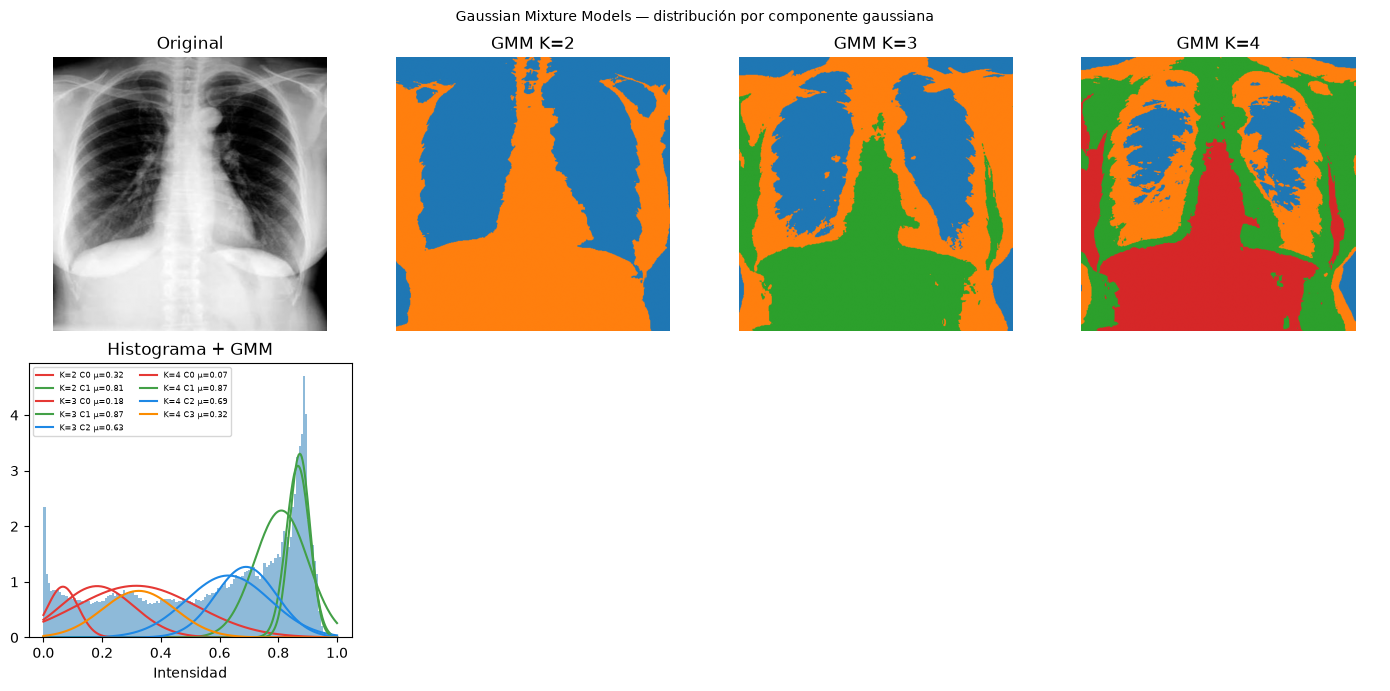

In [35]:
from sklearn.mixture import GaussianMixture

pixels_2d = img.ravel().reshape(-1,1).astype(np.float32)

n_components_list = [2, 3, 4]
fig, axes = plt.subplots(2, len(n_components_list)+1, figsize=(14,7))

axes[0,0].imshow(img,cmap="gray"); axes[0,0].set_title("Original"); axes[0,0].axis("off")
x_hist = np.linspace(0,1,300).reshape(-1,1)
axes[1,0].hist(pixels_2d, bins=128, color="#1f77b4", edgecolor="none", density=True, alpha=0.5)
axes[1,0].set_title("Histograma + GMM"); axes[1,0].set_xlabel("Intensidad")

colors_gmm = ["#E53935","#43A047","#1E88E5","#FB8C00"]
for idx, k in enumerate(n_components_list):
    gmm    = GaussianMixture(n_components=k, random_state=42, max_iter=200)
    gmm.fit(pixels_2d)
    labels_gmm = gmm.predict(pixels_2d).reshape(img.shape)
    probs_gmm  = gmm.predict_proba(pixels_2d)

    order_g = np.argsort(gmm.means_.ravel())
    remap_g = {old:new for new,old in enumerate(order_g)}
    labels_g= np.vectorize(remap_g.get)(labels_gmm)

    axes[0,idx+1].imshow(labels_g, cmap="tab10", vmin=0, vmax=9)
    axes[0,idx+1].set_title(f"GMM K={k}"); axes[0,idx+1].axis("off")

    from scipy.stats import norm
    for ci in range(k):
        mu_g  = gmm.means_[ci,0]
        std_g = np.sqrt(gmm.covariances_[ci,0,0])
        w_g   = gmm.weights_[ci]
        axes[1,0].plot(x_hist, w_g*norm.pdf(x_hist, mu_g, std_g),
                       color=colors_gmm[ci % len(colors_gmm)], lw=1.5,
                       label=f"K={k} C{ci} μ={mu_g:.2f}")

axes[1,0].legend(fontsize=6, ncol=2)
for i in range(1, len(n_components_list)+1):
    axes[1,i].axis("off")

fig.suptitle("Gaussian Mixture Models — distribución por componente gaussiana", fontsize=10)
plt.tight_layout(); plt.show()

<a id="ml_clasico"></a>

## 6. Aprendizaje Automático Clásico
### *Classical Machine Learning for Segmentation*

Se extrae un **vector de características** por píxel o por región —intensidad, textura, coordenadas, gradiente— y se entrena un clasificador supervisado para asignar etiquetas (pulmón / no pulmón, lesión / tejido sano, etc.) (Mansoor et al., 2015).

**Características típicas por píxel:**

| Característica | Descripción |
|---------------|-------------|
| Intensidad | Valor de gris normalizado |
| Gradiente | Magnitud Sobel local |
| LBP | Textura local binaria |
| Coordenadas (x, y) | Posición espacial |
| Vecindario | Intensidades en ventana n×n |

**Clasificadores comunes:** Random Forest · SVM · k-NN · AdaBoost.

> La siguiente celda simula un clasificador píxel a píxel usando Random Forest con características de intensidad, gradiente y posición, entrenado sobre una máscara de referencia generada con Otsu.

[Volver a la Tabla de Contenidos](#toc)

---

c:\Users\bernarda.salazar\AppData\Local\anaconda3\Lib\site-packages\skimage\feature\texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


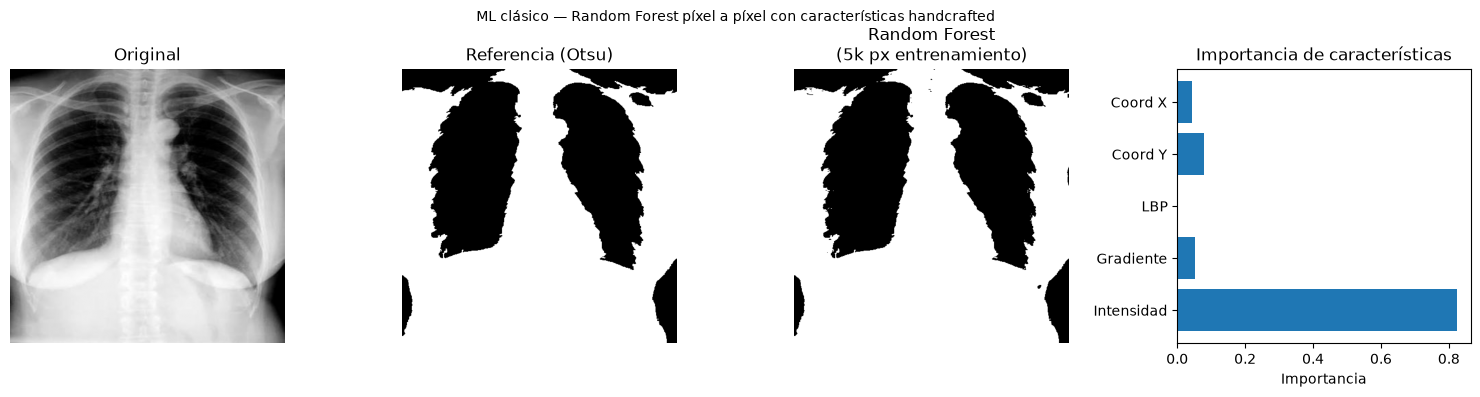

Características usadas: ['Intensidad', 'Gradiente', 'LBP', 'Coord Y', 'Coord X']
Importancias:           [0.823 0.052 0.003 0.079 0.043]


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from skimage.feature import local_binary_pattern
from skimage.filters import sobel

# ── Construcción del vector de características por píxel ──────────────────
H, W = img.shape

# Características
intensity  = img.ravel()
grad_map   = sobel(img).ravel()
lbp_map    = local_binary_pattern(img, P=8, R=1, method="uniform").ravel()
lbp_norm   = lbp_map / lbp_map.max()
yy, xx     = np.mgrid[0:H, 0:W]
coord_y    = (yy / H).ravel()
coord_x    = (xx / W).ravel()

X_feat = np.column_stack([intensity, grad_map, lbp_norm, coord_y, coord_x])

# Etiquetas de referencia (Otsu como proxy de "pulmón")
from skimage.filters import threshold_otsu
y_ref = (img > threshold_otsu(img)).ravel().astype(int)

# Submuestreo para rapidez (5 000 píxeles de entrenamiento)
rng   = np.random.default_rng(0)
idx_s = rng.choice(len(X_feat), size=5_000, replace=False)
X_tr, y_tr = X_feat[idx_s], y_ref[idx_s]

# ── Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=80, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
pred_rf = rf.predict(X_feat).reshape(H, W)

# Importancia de características
feat_names = ["Intensidad", "Gradiente", "LBP", "Coord Y", "Coord X"]
importances = rf.feature_importances_

fig, axes = plt.subplots(1, 4, figsize=(15,4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(binary_otsu_c, cmap="gray"); axes[1].set_title("Referencia (Otsu)"); axes[1].axis("off")
axes[2].imshow(pred_rf, cmap="gray"); axes[2].set_title("Random Forest\n(5k px entrenamiento)"); axes[2].axis("off")
axes[3].barh(feat_names, importances, color="#1f77b4")
axes[3].set_xlabel("Importancia"); axes[3].set_title("Importancia de características")
fig.suptitle("ML clásico — Random Forest píxel a píxel con características handcrafted", fontsize=10)
plt.tight_layout(); plt.show()

print("Características usadas:", feat_names)
print("Importancias:          ", importances.round(3))

<a id="deep_learning"></a>

## 7. Deep Learning para Segmentación

> Actualmente son las técnicas con mayor desempeño en segmentación de imágenes médicas. Aprenden representaciones jerárquicas directamente de los datos.

### Arquitectura encoder–decoder

El paradigma dominante en segmentación semántica con CNN es el **encoder–decoder**:

- **Encoder** (contracción): extrae características mediante convoluciones y pooling, reduciendo la resolución espacial y aumentando la profundidad de características.
- **Decoder** (expansión): reconstruye el mapa de segmentación a resolución original mediante transposiciones de convolución (*upsampling*) y conexiones de salto (*skip connections*).

### Modelos principales para RX de tórax

| Modelo | Innovación clave | Referencia |
|--------|-----------------|------------|
| **FCN** | Primera CNN totalmente convolucional para segmentación | Long et al. (2015) |
| **U-Net** | Skip connections simétricas encoder–decoder | Ronneberger et al. (2015) |
| **U-Net++** | Nodos intermedios densamente conectados | Zhou et al. (2019) |
| **Attention U-Net** | Mecanismos de atención en las skip connections | Oktay et al. (2018) |
| **DeepLab v3+** | Convoluciones atrous + ASPP + decoder liviano | Chen et al. (2018) |

**U-Net y sus variantes son particularmente comunes para segmentar pulmones, corazón y lesiones en RX de tórax** (Ronneberger et al., 2015).

[Volver a la Tabla de Contenidos](#toc)

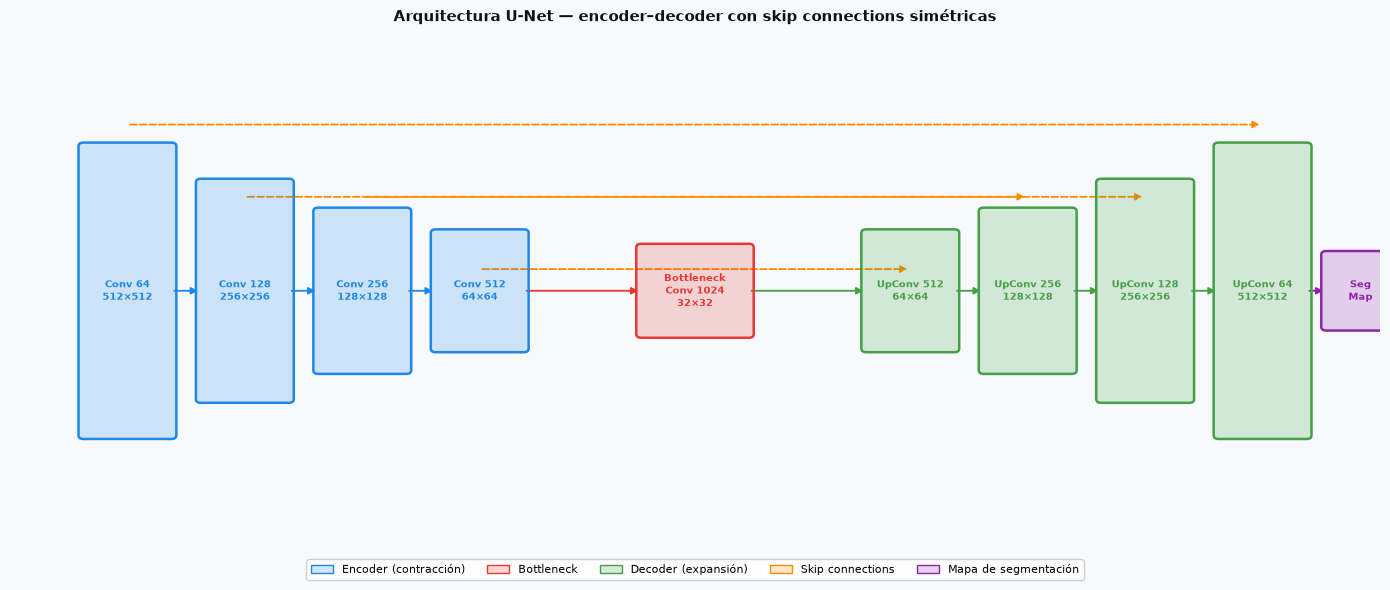

In [37]:
# Diagrama conceptual de U-Net (sin entrenamiento — ilustración arquitectónica)
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14); ax.set_ylim(0, 7)
ax.axis("off"); ax.set_facecolor("#F7F9FC"); fig.patch.set_facecolor("#F7F9FC")

# Colores
col_enc  = "#1E88E5"
col_bot  = "#E53935"
col_dec  = "#43A047"
col_skip = "#FB8C00"
col_out  = "#8E24AA"

def draw_block(ax, x, y, w, h, color, label, fontsize=7.5):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                    boxstyle="round,pad=0.05",
                                    facecolor=color+"33", edgecolor=color,
                                    linewidth=1.8, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, label, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", color=color, zorder=4)

def arrow(ax, x1,y1,x2,y2, color="#555555", style="-|>"):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle=style, color=color, lw=1.3), zorder=2)

# Encoder
enc_x = [1.2, 2.4, 3.6, 4.8]
enc_h = [4.0, 3.0, 2.2, 1.6]
enc_labels = ["Conv 64\n512×512", "Conv 128\n256×256", "Conv 256\n128×128", "Conv 512\n64×64"]
for i,(x,h,lbl) in enumerate(zip(enc_x, enc_h, enc_labels)):
    draw_block(ax, x, 3.5, 0.9, h, col_enc, lbl)
    if i>0: arrow(ax, enc_x[i-1]+0.45, 3.5, x-0.45, 3.5, col_enc)

# Bottleneck
draw_block(ax, 7.0, 3.5, 1.1, 1.2, col_bot, "Bottleneck\nConv 1024\n32×32")
arrow(ax, enc_x[-1]+0.45, 3.5, 7.0-0.55, 3.5, col_bot)

# Decoder
dec_x = [9.2, 10.4, 11.6, 12.8]
dec_h = [1.6, 2.2, 3.0, 4.0]
dec_labels = ["UpConv 512\n64×64", "UpConv 256\n128×128", "UpConv 128\n256×256", "UpConv 64\n512×512"]
for i,(x,h,lbl) in enumerate(zip(dec_x, dec_h, dec_labels)):
    draw_block(ax, x, 3.5, 0.9, h, col_dec, lbl)
    if i==0: arrow(ax, 7.0+0.55, 3.5, x-0.45, 3.5, col_dec)
    else:    arrow(ax, dec_x[i-1]+0.45, 3.5, x-0.45, 3.5, col_dec)

# Skip connections
for ex, dx in zip(enc_x, reversed(dec_x)):
    ax.annotate("", xy=(dx, 3.5+dec_h[dec_x.index(dx)]//2+0.3),
                xytext=(ex, 3.5+enc_h[enc_x.index(ex)]//2+0.3),
                arrowprops=dict(arrowstyle="-|>", color=col_skip,
                                lw=1.3, linestyle="dashed"), zorder=2)

# Output
draw_block(ax, 13.8, 3.5, 0.7, 1.0, col_out, "Seg\nMap")
arrow(ax, 12.8+0.45, 3.5, 13.8-0.35, 3.5, col_out)

# Leyenda
patches = [
    mpatches.Patch(facecolor=col_enc+"33", edgecolor=col_enc, label="Encoder (contracción)"),
    mpatches.Patch(facecolor=col_bot+"33", edgecolor=col_bot, label="Bottleneck"),
    mpatches.Patch(facecolor=col_dec+"33", edgecolor=col_dec, label="Decoder (expansión)"),
    mpatches.Patch(facecolor=col_skip+"33",edgecolor=col_skip,label="Skip connections"),
    mpatches.Patch(facecolor=col_out+"33", edgecolor=col_out, label="Mapa de segmentación"),
]
ax.legend(handles=patches, loc="upper center", bbox_to_anchor=(0.5,-0.02),
          ncol=5, fontsize=8, frameon=True, framealpha=0.95)
ax.set_title("Arquitectura U-Net — encoder–decoder con skip connections simétricas",
             fontsize=11, fontweight="bold", color="#111111", pad=12)
plt.tight_layout(); plt.show()

<a id="recientes"></a>

## 8. Modelos Más Recientes

### 8.1 nnU-Net

**nnU-Net** (*no-new-U-Net*) es un framework que configura automáticamente los componentes del pipeline de segmentación —preprocesamiento, arquitectura, entrenamiento y postprocesamiento— a partir de las propiedades del dataset (Isensee et al., 2021). Ha establecido el estado del arte en numerosos benchmarks de segmentación médica.

**Características:**
- Selección automática de arquitectura (2D, 3D o cascada).
- Normalización e intensidad adaptativas.
- Ensemble de modelos por validación cruzada.

---

### 8.2 Segmentation Transformers (ViT / Swin)

Los **Vision Transformers (ViT)** reemplazan las convoluciones locales por mecanismos de **auto-atención** global, capturando dependencias de largo alcance en la imagen. Modelos como **Swin-UNet** adaptan el Swin Transformer a la arquitectura encoder–decoder para segmentación médica (Cao et al., 2023).

**Ventaja:** capturan contexto global de la imagen, útil para delimitar estructuras grandes como campos pulmonares completos.

---

### 8.3 SAM — Segment Anything Model

**SAM** (Kirillov et al., 2023) es un modelo fundacional entrenado en más de 1 000 millones de máscaras. Puede generar o refinar máscaras a partir de prompts (puntos, cajas o texto). Su desempeño en imágenes médicas depende del tipo de imagen y del ajuste (*fine-tuning*) del modelo; variantes como **MedSAM** lo adaptan específicamente a imágenes clínicas.

| Modelo | Año | Tipo | Aplicación en RX |
|--------|-----|------|-----------------|
| U-Net | 2015 | CNN | Pulmones, corazón, lesiones |
| Attention U-Net | 2018 | CNN + Atención | Nódulos, estructuras finas |
| nnU-Net | 2021 | AutoML + CNN | Benchmarks multi-órgano |
| Swin-UNet | 2022 | Transformer | Contexto global pulmonar |
| MedSAM | 2023 | Foundation Model | Segmentación interactiva |

[Volver a la Tabla de Contenidos](#toc)

---

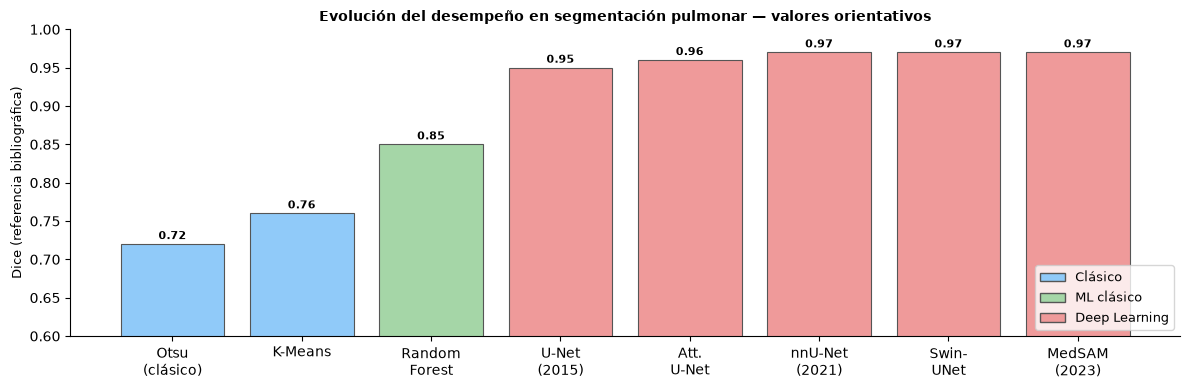

In [38]:
# Comparativa conceptual: evolución del desempeño en segmentación pulmonar en RX
# (valores representativos de Dice en datasets públicos — no reproducidos aquí)

modelos   = ["Otsu\n(clásico)", "K-Means", "Random\nForest", "U-Net\n(2015)",
             "Att.\nU-Net", "nnU-Net\n(2021)", "Swin-\nUNet", "MedSAM\n(2023)"]
dice_ref  = [0.72, 0.76, 0.85, 0.95, 0.96, 0.97, 0.97, 0.97]
familia   = ["Clásico"]*2 + ["ML clásico"] + ["Deep Learning"]*5
colores_f = {"Clásico":"#90CAF9", "ML clásico":"#A5D6A7", "Deep Learning":"#EF9A9A"}
bar_colors= [colores_f[f] for f in familia]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(modelos, dice_ref, color=bar_colors, edgecolor="#555555", linewidth=0.8)
ax.set_ylim(0.60, 1.00); ax.set_ylabel("Dice (referencia bibliográfica)", fontsize=9)
ax.set_title("Evolución del desempeño en segmentación pulmonar — valores orientativos",
             fontsize=10, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
for bar, v in zip(bars, dice_ref):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f"{v:.2f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

legend_patches = [mpatches.Patch(facecolor=v, edgecolor="#555", label=k)
                  for k,v in colores_f.items()]
ax.legend(handles=legend_patches, fontsize=9, frameon=True, loc="lower right")
plt.tight_layout(); plt.show()

<a id="comparativa"></a>

## 9. Comparativa Visual de Técnicas Implementadas

La siguiente celda reproduce en un único panel las segmentaciones obtenidas con los métodos clásicos e implementados en este notebook sobre la misma radiografía de referencia.

| Técnica | Tipo | Parámetros clave | Ventaja | Limitación |
|---------|------|-----------------|---------|------------|
| Otsu | Umbral global | — (automático) | Sin parámetros | Iluminación no uniforme |
| Adaptativa | Umbral local | block_size, C | Robusta a gradientes | Sensible a ruido fino |
| Region Growing | Región | semilla, Δ | Controla crecimiento | Sensible a inicialización |
| Watershed | Región + borde | marcadores | Separa solapamientos | Sobre-segmenta sin buenos marcadores |
| Snake | Contorno activo | α, β | Bordes precisos | Requiere inicialización cercana |
| K-Means | Clustering | K | Agrupa por densidad | Sensible a orden de inicio |
| FCM | Clustering suave | K, m | Pertenencia continua | Lento en imágenes grandes |
| GMM | Clustering prob. | K | Modela distribución | Asume gaussianidad |
| Random Forest | ML supervisado | n_trees, depth | Importancia de features | Requiere anotaciones |
| Canny | Detección bordes | σ, T_low, T_high | Bordes de 1 px | Solo bordes, no regiones |

[Volver a la Tabla de Contenidos](#toc)

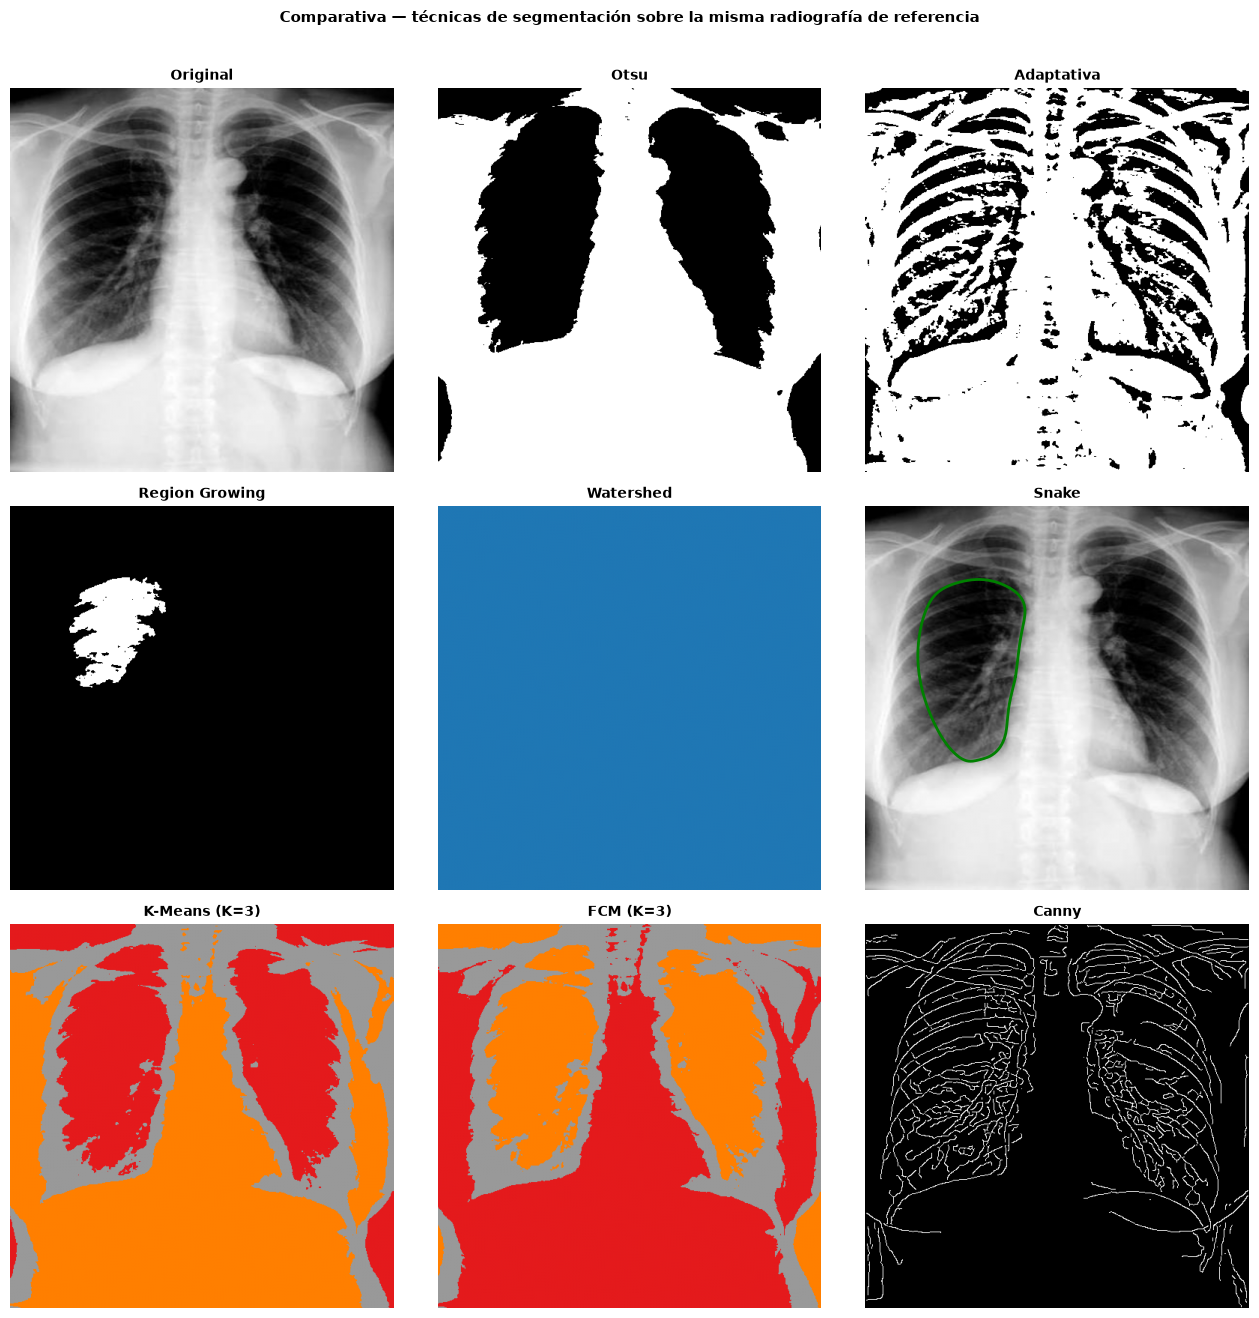

In [39]:
from skimage.filters import threshold_otsu, threshold_local, sobel, gaussian
from skimage.feature import canny
from skimage.morphology import binary_closing, disk
from skimage.segmentation import watershed, mark_boundaries
from sklearn.cluster import MiniBatchKMeans
from scipy import ndimage as ndi
from skimage.feature import peak_local_max

# Recomputar todas las técnicas
t_otsu      = threshold_otsu(img);  seg_otsu   = img > t_otsu
seg_adapt   = img > threshold_local(img, block_size=61, offset=0.02)
seg_rg      = region_growing(img, (int(TARGET*0.20), int(TARGET*0.30)), delta=0.10)

grad_ws     = sobel(img)
sm_g        = gaussian(grad_ws, 2)
lm          = peak_local_max(-sm_g, min_distance=20, threshold_rel=0.05)
mk          = np.zeros(img.shape, dtype=bool); mk[tuple(lm.T)] = True
mk_l, _     = ndi.label(mk)
seg_ws      = watershed(grad_ws, mk_l)

img_sm      = gaussian(img, sigma=3)
cx2,cy2     = TARGET*0.28, TARGET*0.50
rx2,ry2     = TARGET*0.18, TARGET*0.32
theta2      = np.linspace(0,2*np.pi,400)
init2       = np.column_stack([cy2+ry2*np.sin(theta2), cx2+rx2*np.cos(theta2)])
from skimage.segmentation import active_contour
snake2      = active_contour(img_sm, init2, alpha=0.015, beta=10, gamma=0.001, max_num_iter=250)

pix2d       = img.ravel().reshape(-1,1).astype(np.float32)
km_r        = MiniBatchKMeans(n_clusters=3, random_state=42, n_init=5).fit_predict(pix2d).reshape(img.shape)
fcm_l, _, _ = fuzzy_cmeans(img.ravel().astype(np.float32), n_clusters=3)
fcm_r       = fcm_l.reshape(img.shape)
edges_c     = canny(img, sigma=1.5, low_threshold=0.05, high_threshold=0.15)

methods = [
    ("Original",       img,       "gray"),
    ("Otsu",           seg_otsu,  "gray"),
    ("Adaptativa",     seg_adapt, "gray"),
    ("Region Growing", seg_rg,    "gray"),
    ("Watershed",      seg_ws,    "tab20"),
    ("Snake",          img,       "gray"),   # contorno superpuesto
    ("K-Means (K=3)",  km_r,      "Set1"),
    ("FCM (K=3)",      fcm_r,     "Set1"),
    ("Canny",          edges_c,   "gray"),
]

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes_flat  = axes.ravel()

for i, (name, im_m, cmap_m) in enumerate(methods):
    ax = axes_flat[i]
    ax.imshow(im_m, cmap=cmap_m); ax.axis("off")
    ax.set_title(name, fontsize=10, fontweight="bold")
    if name == "Snake":
        ax.plot(snake2[:,1], snake2[:,0], "-g", lw=2)

fig.suptitle("Comparativa — técnicas de segmentación sobre la misma radiografía de referencia",
             fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

<a id="referencias"></a>

## Referencias

Adams, R., & Bischof, L. (1994). Seeded region growing. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, *16*(6), 641–647. 

Beucher, S., & Lantuéjoul, C. (1979). Use of watersheds in contour detection. *Proceedings of the International Workshop on Image Processing: Real-time Edge and Motion Detection/Estimation*. CCETT.

Bezdek, J. C., Hall, L. O., & Clarke, L. P. (1993). Review of MR image segmentation techniques using pattern recognition. *Medical Physics*, *20*(4), 1033–1048. 

Bradley, D., & Roth, G. (2007). Adaptive thresholding using the integral image. *Journal of Graphics Tools*, *12*(2), 13–21. 

Candemir, S., & Antani, S. (2019). A review of pulmonary medical image segmentation algorithms for apparent diffusion coefficient maps. *Journal of Medical Imaging*, *6*(2), 020601. 

Cao, H., Wang, Y., Chen, J., Jiang, D., Zhang, X., Tian, Q., & Wang, M. (2023). Swin-UNet: Unet-like pure transformer for medical image segmentation. *Lecture Notes in Computer Science*, *13803*, 205–218.

Canny, J. (1986). A computational approach to edge detection. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, *PAMI-8*(6), 679–698. 

Chen, L.-C., Zhu, Y., Papandreou, G., Schroff, F., & Adam, H. (2018). Encoder-decoder with atrous separable convolution for semantic image segmentation. *Proceedings of ECCV 2018*, 801–818. 

Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). Maximum likelihood from incomplete data via the EM algorithm. *Journal of the Royal Statistical Society: Series B*, *39*(1), 1–22. 

Isensee, F., Jaeger, P. F., Kohl, S. A. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: A self-configuring method for deep learning-based biomedical image segmentation. *Nature Methods*, *18*(2), 203–211. 

Jain, A. K., & Farrokhnia, F. (1991). Unsupervised texture segmentation using Gabor filters. *Pattern Recognition*, *24*(12), 1167–1186. 

Kass, M., Witkin, A., & Terzopoulos, D. (1988). Snakes: Active contour models. *International Journal of Computer Vision*, *1*(4), 321–331. 

Kirillov, A., Mintun, E., Ravi, N., Mao, H., Rolland, C., Gustafson, L., Xiao, T., Whitehead, S., Berg, A. C., Lo, W.-Y., Dollár, P., & Girshick, R. (2023). Segment anything. *Proceedings of ICCV 2023*. 

Long, J., Shelhamer, E., & Darrell, T. (2015). Fully convolutional networks for semantic segmentation. *Proceedings of CVPR 2015*, 3431–3440. 

MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability*, *1*, 281–297.

Mansoor, A., Bagci, U., Foster, B., Xu, Z., Papadakis, G. Z., Folio, L. R., Udupa, J. K., & Mollura, D. J. (2015). Segmentation and image analysis of abnormal lungs at CT: Current approaches, challenges, and future trends. *RadioGraphics*, *35*(4), 1056–1076. 

Oktay, O., Schlemper, J., Le Folgoc, L., Lee, M., Heinrich, M., Misawa, K., Mori, K., McDonagh, S., Hammerla, N. Y., Kainz, B., Glocker, B., & Rueckert, D. (2018). *Attention U-Net: Learning where to look for the pancreas*. arXiv:1804.03999. 


Otsu, N. (1979). A threshold selection method from gray-level histograms. *IEEE Transactions on Systems, Man, and Cybernetics*, *9*(1), 62–66. 

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. *Proceedings of MICCAI 2015*, *9351*, 234–241.

Zhou, Z., Rahman Siddiquee, M. M., Tajbakhsh, N., & Liang, J. (2019). UNet++: Redesigning skip connections to exploit multiscale features in image segmentation. *IEEE Transactions on Medical Imaging*, *39*(6), 1856–1867. 

---

<p style='text-align:center;color:gray;font-size:.9em'>
Técnicas de Segmentación en RX de Tórax &nbsp;·&nbsp; Maria Bernarda Salazar Sánchez
</p>